
<a id="summary"></a>

## Notebook 3 — RFM scoring & clustering (behavioral segments)

**v1.** This notebook engineers **RFM features** at **customer** grain (on top of completed transactions), prepares **clustering** on behavioral patterns, and targets roadmap **Q6–Q10** from `docs/fintech-ai-segmentation-summary.md`.

### How this notebook is organized

**Jump to parts:** 

1. [Part 1 — RFM design & data loading](#part-1)
2. [Part 2 — RFM metrics and Feature Engineering]((#part-2))
3. [Part 3 — clustering & segment profiles]((#part-3))
4. [Part 4 — products & utilization]((#part-4))

**Part 1 — RFM design & data loading**

1.1 [RFM ranking criteria (locked definitions)](#rfm-criteria)
1.2 [Load raw tables from Supabase](#q1)
1.3 [Join transactions to customer attributes](#q2)
1.4 [Analysis window & transaction month buckets](#q3)

---

### Objectives

- **This pass:** Document **RFM criteria**, import libraries, load **`customers_raw`**, **`transactions_raw`**, **`products_raw`**, **`customer_products_raw`**, build **`df_tx`**, restrict to the **2024-03–2026-02** analysis window, and pin **`as_of_date`**. **F** and **M** use the **full retained history** within that window (no extra 12-month cap).
- **Later:** Quintile scores, K-Means / segments, answers to Q6–Q10 (including product counts and credit utilization when features exist).

### Business questions (Behavioral Intelligence)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments? *(requires engineered `customers_features` or a documented proxy — see [RFM criteria](#rfm-criteria).)*

### Expected output

- **`df_tx`**: completed transactions joined to customers, restricted to **`transaction_datetime` in [2024-03-01, 2026-03-01)** (Mar 2024–Feb 2026 inclusive by month).
- **`as_of_date`**: reference instant for **recency**; **frequency** and **monetary** are computed over **all** completed transactions in that window with `transaction_datetime` ≤ `as_of_date`.
- **`df_products`**, **`df_customer_products`**: for product-ownership analysis (Q9).
- Later: per-customer **`recency_days`**, **`frequency`** (count), **`monetary`** (sum), quintile scores, **`rfm_score`**, **`predicted_segment`**.



<a id="rfm-criteria"></a>

### RFM ranking criteria (v1)

These definitions stay aligned with [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) calendar rules and with [`docs/notebooks-roadmap.md`](docs/notebooks-roadmap.md) Notebook 4.


| Topic | Rule |
|-------|------|
| **Analysis window** | Keep completed transactions with **`transaction_datetime`** in **[2024-03-01, 2026-03-01)** (calendar months **2024-03** through **2026-02**). Then derive `transaction_month` / `registration_month`. |
| **`as_of_date`** | **`max(transaction_datetime)`** on those retained **`df_tx`** rows (end of the analysis window for RFM). |
| **Recency (R)** | Days from **`as_of_date`** to each customer's **last** completed transaction timestamp (`>= 0`). Customers with no transaction in the retained data are out of scope for RFM until handled explicitly. |
| **Frequency (F)** | Count of completed transactions per customer with `transaction_datetime` **≤ `as_of_date`**, over the **full analysis window** (Mar 2024–Feb 2026). |
| **Monetary (M)** | Sum of **`amount`** over the **same rows as F**. Exclude **`transaction_type = 'refund'`** from F and M when that column is present (or net, if you define a refund rule). |
| **Scores 1–5** | **Quintiles** on each dimension among eligible customers: higher score = more recent (lower days), higher frequency, higher monetary. Ties: use `method='first'` in `pandas.qcut` unless we document otherwise. |
| **Combined `rfm_score`** | For ordering: **`100 * R_score + 10 * F_score + M_score`** (so lexicographic R → F → M). For reporting, also keep the three scores separate. |


[↑ Back to summary](#summary)


In [1]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes), restrict to the **2024-03–2026-02** analysis window, and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [2]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  age,\n"
    "  state,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [3]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 7)


,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,CE,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,BA,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,MS,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,PE,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


In [4]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (2031570, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed


In [5]:
print("df_products:", df_products.shape)
display(df_products.head())


df_products: (5, 3)


,product_id,product_name,product_type
0,217b207a-9807-4785-8d72-7efd0feee310,Digital Wallet,wallet
1,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,SynaptiqPay Credit Card,credit_card
2,1a669298-c14d-40ca-886d-080df620b493,Investment Account,investment
3,8220d026-90e5-4f54-81ef-a00aca9ce261,Device Insurance,insurance
4,9b0a3075-54a6-4f6a-bc64-ccd32b737ab7,Personal Loan,loan


In [6]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19902, 4)


,customer_id,product_id,start_date,is_active
0,0b8f3bda-d929-4111-abd9-992ac76066a9,217b207a-9807-4785-8d72-7efd0feee310,2024-09-21 00:00:00+00:00,True
1,0b8f3bda-d929-4111-abd9-992ac76066a9,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-08-04 00:00:00+00:00,True
2,0b8f3bda-d929-4111-abd9-992ac76066a9,1a669298-c14d-40ca-886d-080df620b493,2026-02-06 00:00:00+00:00,True
3,f96dacb9-92bb-4094-977c-0de351bebff0,217b207a-9807-4785-8d72-7efd0feee310,2024-06-22 00:00:00+00:00,True
4,f96dacb9-92bb-4094-977c-0de351bebff0,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-12-16 00:00:00+00:00,True



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

[↑ Back to summary](#summary)


In [7]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")



<a id="q3"></a>

### 3. Analysis window & transaction month buckets

Restrict **`df_tx`** to transactions in **2024-03 through 2026-02** (`transaction_datetime` in **[2024-03-01, 2026-03-01)**). Then normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps and ensure **`amount`** is numeric.

**`as_of_date`** is the maximum **`transaction_datetime`** within this window (end of RFM observation for recency and full-window F/M).

[↑ Back to summary](#summary)


In [8]:

# Analysis window: Mar 2024 through Feb 2026 (inclusive on transaction month)
# Keep rows with transaction_datetime in [2024-03-01, 2026-03-01)
WINDOW_START = pd.Timestamp("2024-03-01")
WINDOW_END_EXCL = pd.Timestamp("2026-03-01")

_tx = df_tx["transaction_datetime"]
if isinstance(_tx.dtype, pd.DatetimeTZDtype):
    _tx = _tx.dt.tz_convert("UTC").dt.tz_localize(None)

_window_mask = (_tx >= WINDOW_START) & (_tx < WINDOW_END_EXCL)
_n_before = len(df_tx)
df_tx = df_tx.loc[_window_mask].copy()
print(
    f"Analysis window 2024-03 .. 2026-02: rows {_n_before:,} -> {len(df_tx):,}"
)

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

print("df_tx (joined, windowed):", df_tx.shape)
display(df_tx.head())

# Latest calendar month observed in this window
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Analysis window 2024-03 .. 2026-02: rows 2,031,570 -> 1,342,806
df_tx (joined, windowed): (1342806, 16)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
313,843e890a-5778-4e57-8c52-39c92c39c3db,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-06 15:41:00+00:00,267.00,purchase,wallet,card_present,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
314,279635b4-9624-4560-9a23-7e7c1a0c0afa,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-26 10:19:00+00:00,135.31,purchase,wallet,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
315,7088a830-6b42-426b-81a0-1390b4f29a3c,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-07 21:17:00+00:00,270.30,purchase,wallet,in_app,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
316,0030e3d0-ab33-43f2-8c42-08fdfac93c48,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-25 07:42:00+00:00,203.04,purchase,investment,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
317,147004c5-c0d3-4b61-8944-3d67cc83d131,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-14 14:50:00+00:00,153.28,transfer,credit_card,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01


latest_complete_month: 2026-02
as_of_date: 2026-02-28 23:58:00+00:00


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_10238/3296164742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")


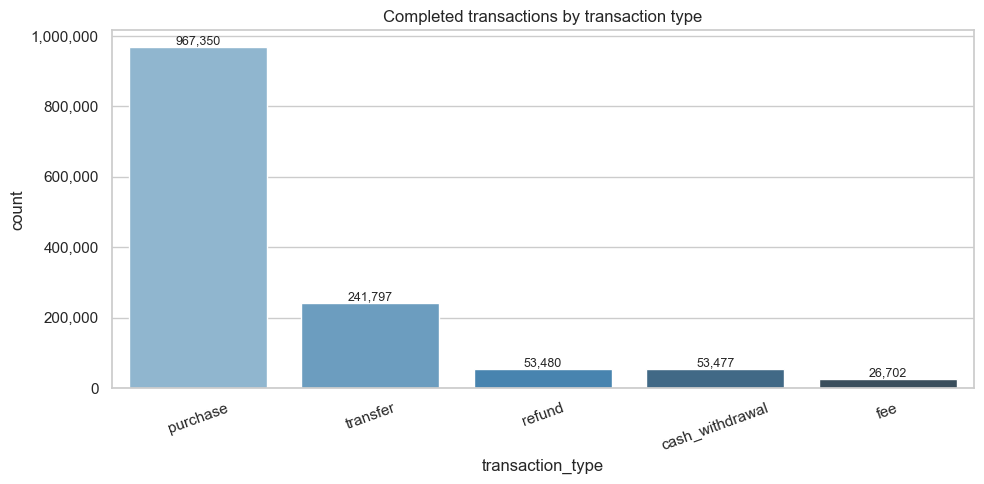

transaction_type
purchase           967350
transfer           241797
refund              53480
cash_withdrawal     53477
fee                 26702
Name: count, dtype: int64

In [9]:

# Transaction type distribution (absolute counts)
vc_tx_type = (
    df_tx["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")
ax.set_title("Completed transactions by transaction type")
ax.set_xlabel("transaction_type")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

for i, v in enumerate(vc_tx_type.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

vc_tx_type


This chart above shows a strongly purchase-led transaction mix: purchases account for the vast majority of completed operations, while transfer form a secondary tier. Fee, cash withdrawal and refund are comparatively small, which is expected operationally, but still useful to monitor as quality signals. Overall, user behavior looks concentrated in value-generating transactions, with limited reversal activity.

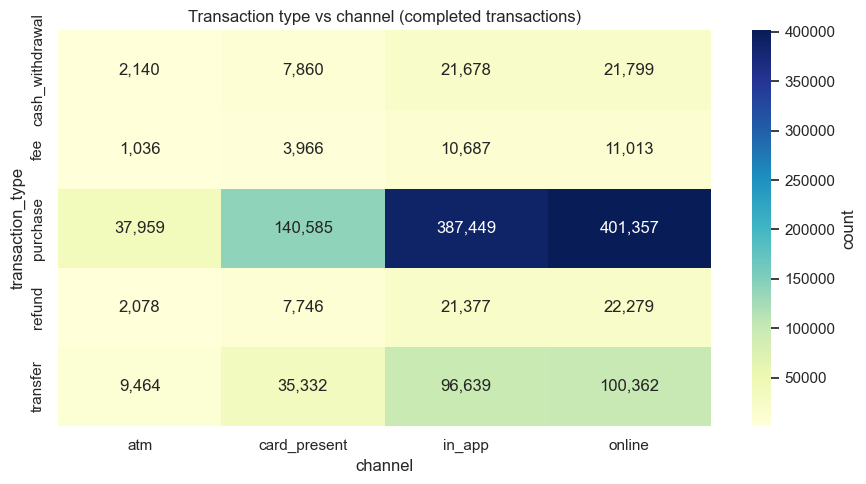

In [10]:
# Heatmap: transaction_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["transaction_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Transaction type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("transaction_type")

plt.tight_layout()
plt.show()


**Purchases** dominate overall volume. For purchases, **online** (401,357) slightly edges **in_app** (387,449); **card_present** (140,585) is next, and **atm** (37,959) is far smaller. **Transfers** follow the same digital skew (**online** 100,362 vs **in_app** 96,639). **ATM** is the smallest channel for every transaction type—physical rails are niche, not the default journey.

**Actionable insight:** Invest jointly in **web + app** purchase funnels (A/B by step, latency, failures) since both carry the majority of revenue-adjacent volume. Treat **card_present** as a partner/merchant lane worth its own CAC and experience KPIs. Revisit **ATM** economics—optimize for a small “cash access” segment or trim fixed cost if volume stays flat. For **transfers**, prioritize digital capabilities (limits, scheduling, instant settlement) where users already cluster.

**Segmentation note:** Channel *ranking* looks similar across transaction types (digital first, ATM last), so clusters will likely separate more on **intensity, ticket, and product mix** than on a radically different channel preference—use channel shares as supporting features alongside RFM.


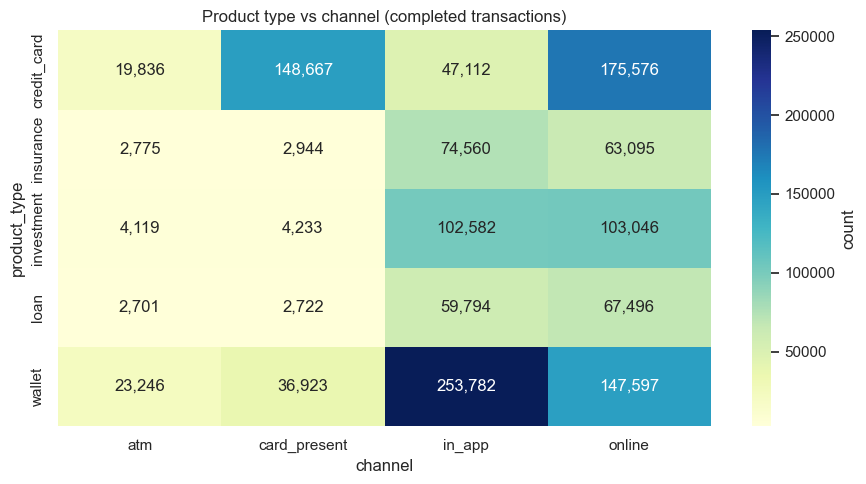

In [11]:
# Heatmap: product_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["product_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Product type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("product_type")

plt.tight_layout()
plt.show()


Wallet concentrates in in_app and online, which matches a mobile-first, everyday payments story—prioritize app/Web reliability, limits, and instant notifications on those rails. Credit card activity is relatively strong on card_present and online, so treat in-store and e-commerce partnerships as first-class journeys, not only app flows. Investment, insurance, and loan skew heavily digital (in_app / online) with modest ATM / card_present use—optimize for remote onboarding, education, and frictionless digital servicing; physical channels are niche for these lines.

Actionable insight: Set per-product channel KPIs (conversion, ticket, failure rate) instead of one global funnel: wallet = app/Web growth; credit card = card_present + online acceptance; long-tail products = digital origination and support. Use this matrix to decide where marketing spend and engineering capacity go per product family, and to spot misrouting (e.g., high ATM wallet volume) for fraud or UX review.



<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

[↑ Back to summary](#summary)

customers (all): 8000
clustering frame (frequency_total >= 1): 4884
avg_ticket in df_clustering: True
Correlation matrix (monetary_total and split columns):
                          monetary_total  monetary_purchase  \
monetary_total                  1.000000           0.999503   
monetary_purchase               0.999503           1.000000   
monetary_transfer               0.993921           0.990525   
monetary_cash_withdrawal        0.968246           0.964642   

                          monetary_transfer  monetary_cash_withdrawal  
monetary_total                     0.993921                  0.968246  
monetary_purchase                  0.990525                  0.964642  
monetary_transfer                  1.000000                  0.960856  
monetary_cash_withdrawal           0.960856                  1.000000  
dropped split columns (|corr| > 0.9 with monetary_total): ['monetary_purchase', 'monetary_transfer', 'monetary_cash_withdrawal']
corr(frequency_total, avg_ticket): 0.7

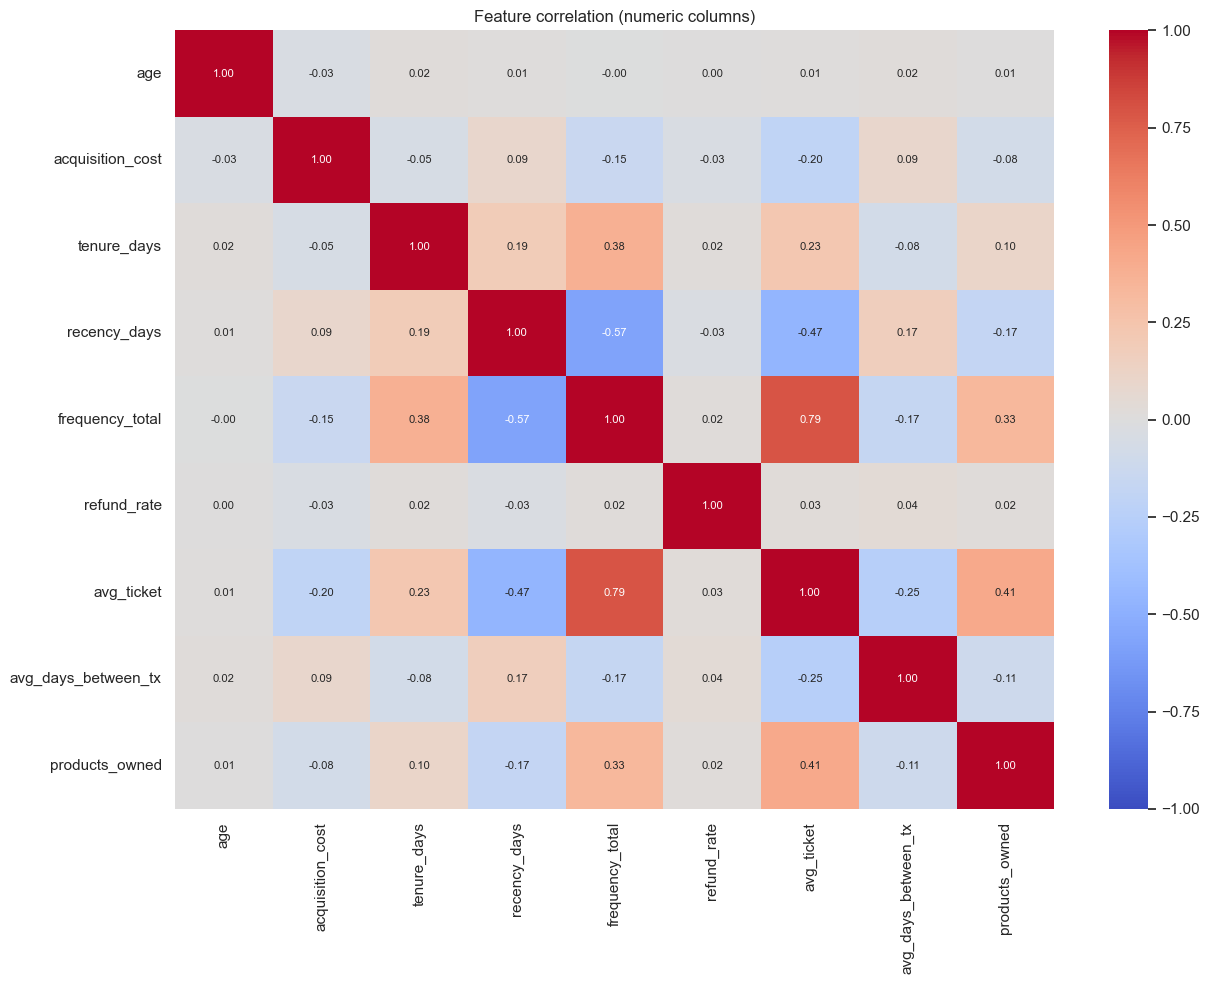

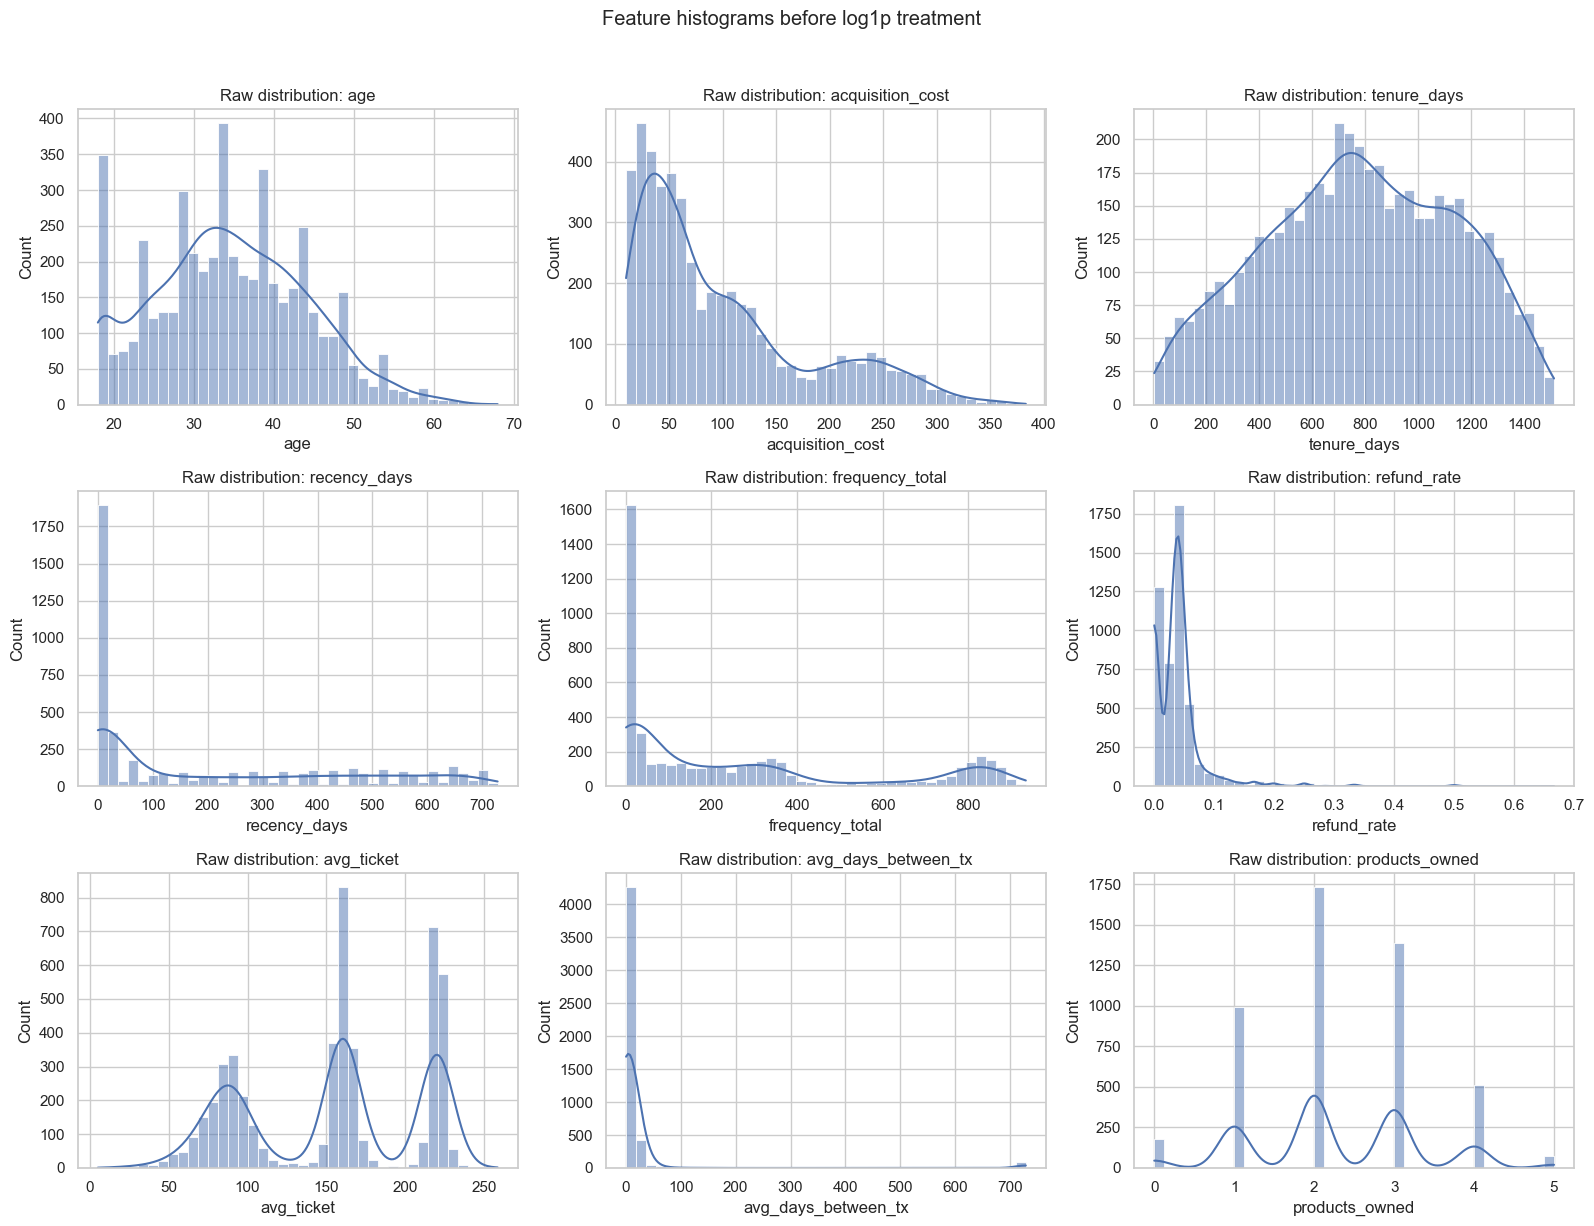

X_scaled shape: (4884, 9)


,mean,std,min,max
recency_days,4.655481e-17,1.000102,-1.375276,1.186574
frequency_total,2.793288e-16,1.000102,-1.990366,1.290796
avg_ticket,-6.983221e-16,1.000102,-7.484448,1.435485
avg_days_between_tx,-1.396644e-16,1.000102,-1.230089,4.315252
acquisition_cost,0.000000e+00,1.000102,-2.183421,1.968584
refund_rate,-1.396644e-16,1.000102,-1.475565,5.933799
age,3.273385e-16,1.000102,-1.729271,3.502699
tenure_days,-1.163870e-17,1.000102,-2.178048,2.057824
products_owned,-6.983221e-17,1.000102,-2.139215,2.579812


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,refund_rate,avg_ticket,avg_days_between_tx,products_owned
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,27.79,981.0,28.0,780.0,174621.79,0.042945,223.874090,0.899945,3.0
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,222.02,882.0,0.0,821.0,184915.37,0.043124,225.231876,0.889248,3.0
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,39.81,1255.0,243.0,565.0,129816.47,0.042373,229.763664,0.859790,1.0
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,52.54,1029.0,28.0,742.0,163106.58,0.041344,219.820189,0.945594,4.0
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,199.99,866.0,1.0,827.0,182653.19,0.037253,220.862382,0.881939,2.0


Fee + other types (mean residual vs monetary_total): 53395.380737100735


In [ ]:
from pathlib import Path
import sys

# Make local src package importable when notebook kernel is not launched via Poetry.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import fintech_ai_segmentation.rfm_features as rfm

# Reload the concrete module directly (avoids package-level export cache issues).
rfm = importlib.reload(rfm)

build_customer_feature_matrix = rfm.build_customer_feature_matrix
build_preprocessing_pipeline = rfm.build_preprocessing_pipeline
drop_correlated_splits = rfm.drop_correlated_splits

# All-numeric feature matrix (no categoricals): behavioral + age + acquisition_cost.
df_features = build_customer_feature_matrix(
    df_tx,
    df_customer_products,
    df_customers,
    as_of_date,
)

# Clustering frame: keep only customers with at least one non-refund transaction.
df_clustering = df_features.loc[df_features["frequency_total"] >= 1].copy()
print("customers (all):", len(df_features))
print("clustering frame (frequency_total >= 1):", len(df_clustering))
print("avg_ticket in df_clustering:", "avg_ticket" in df_clustering.columns)

# Conditional multicollinearity reduction for monetary split columns.
df_clustering, dropped_cols = drop_correlated_splits(df_clustering, threshold=0.9)
print("dropped split columns (|corr| > 0.9 with monetary_total):", dropped_cols)

# Correlation analysis on numeric features used for preprocessing.
# Keep monetary_total for diagnostics, but exclude it from clustering features
# to avoid double-weighting the same spend signal with frequency_total.
feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id", "monetary_total"}
]
if {"frequency_total", "avg_ticket"}.issubset(df_clustering.columns):
    corr_freq_ticket = df_clustering[["frequency_total", "avg_ticket"]].corr().iloc[0, 1]
    print(f"corr(frequency_total, avg_ticket): {corr_freq_ticket:.4f}")
_corr = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation (numeric columns)")
plt.tight_layout()
plt.show()

# Histogram check before log1p treatment (raw feature distributions).
plot_cols = [c for c in feature_cols if c != "customer_id"]
if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df_clustering[col].dropna(), bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"Raw distribution: {col}")

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature histograms before log1p treatment", y=1.02)
    plt.tight_layout()
    plt.show()

# Build and fit preprocessing pipeline (log1p selected cols + StandardScaler).
preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(df_clustering[feature_cols])

print("X_scaled shape:", X_scaled.shape)

# Keep output column names aligned with ColumnTransformer order across sklearn versions.
log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(12))

display(df_clustering.head())

# Fee check: monetary_total ~= purchase + transfer + cash_withdrawal + residual fees
for _col in [
    "monetary_purchase",
    "monetary_transfer",
    "monetary_cash_withdrawal",
]:
    if _col not in df_clustering.columns:
        df_clustering[_col] = 0.0
_fee_residual = (
    df_clustering["monetary_total"]
    - df_clustering["monetary_purchase"]
    - df_clustering["monetary_transfer"]
    - df_clustering["monetary_cash_withdrawal"]
)
print("Fee + other types (mean residual vs monetary_total):", float(_fee_residual.mean()))

**Definitions (v2, preprocessing-only)** — All features are numeric. Behavioral: `recency_days`, `frequency_total`, `monetary_total`, conditional monetary splits, `refund_rate`, `products_owned`, `avg_days_between_tx`. Customer attributes: `age` and `acquisition_cost` (used as proxy for acquisition channel quality). We intentionally drop state and all categorical encodings in this pass.

**Cadence rule:** customers with fewer than two non-refund transactions receive `avg_days_between_tx` imputed with the observed analysis-window span (in days).

**Correlation rule:** if `monetary_purchase`, `monetary_transfer`, or `monetary_cash_withdrawal` has `|corr| > 0.9` against `monetary_total`, that split is dropped before scaling.

**Pipeline in this step:** `log1p` on heavy-tailed columns (`recency_days`, `frequency_total`, `monetary_total`, `avg_days_between_tx`) + `StandardScaler` on all surviving numeric columns.

`true_segment` is intentionally excluded from preprocessing features and kept only for later post-clustering evaluation.